# Infield Modeling Refresh: D1 and P4 (D1-Only)

This notebook rebuilds infield modeling end-to-end with a stricter feature contract:

- **Allowed raw inputs**: `height`, `weight`, `inf_velo`, `exit_velo_max`, `sixty_time`, `throwing_hand`, `hitting_handedness`
- **Everything else is engineered from those inputs**
- Includes **Logistic Regression baselines** for both tasks
- Trains and tunes stronger models, then compares baseline vs best model at the end

Targets:
1. `d1_or_not` on the infield dataset
2. `p4_or_not` on **D1 players only**


## Modeling Plan

1. Load and inspect data quality/class balance
2. Restrict to allowed user-input fields + target labels
3. Engineer advanced features from:
   - physics-style ratios/interactions
   - benchmark z-scores and threshold flags (from constants)
   - elite marker flags
4. Train **original baseline** (LogReg)
5. Tune advanced candidates (XGBoost / LightGBM / CatBoost when available)
6. Build weighted soft-ensemble from tuned candidates
7. Select best model by validation objective and compare on untouched test set
8. Print final classification reports + confusion matrices at bottom


In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import sys
from pathlib import Path
from typing import Dict, Tuple, List, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
)

import optuna
from optuna.samplers import TPESampler

# Optional model libraries (use if installed)
HAS_XGB = False
HAS_LGB = False
HAS_CAT = False

try:
    import xgboost as xgb
    HAS_XGB = True
except Exception:
    pass

try:
    import lightgbm as lgb
    HAS_LGB = True
except Exception:
    pass

try:
    import catboost as cb
    HAS_CAT = True
except Exception:
    pass

RANDOM_STATE = 42
N_TRIALS = 50  # Increase for deeper search if runtime allows

print(f"XGBoost available: {HAS_XGB}")
print(f"LightGBM available: {HAS_LGB}")
print(f"CatBoost available: {HAS_CAT}")
print(f"Optuna trials/model: {N_TRIALS}")


XGBoost available: True
LightGBM available: True
CatBoost available: True
Optuna trials/model: 50


In [ ]:
# Resolve repository root robustly

def find_repo_root(start: Path) -> Path:
    for candidate in [start] + list(start.parents):
        if (candidate / 'backend').exists() and (candidate / 'backend' / 'data').exists():
            return candidate
    return start

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# Pull benchmark and elite constants from project constants
try:
    from backend.constants import DIVISION_BENCHMARKS
    from backend.utils.elite_weighting_constants import (
        ELITE_EXIT_VELO_MAX,
        ELITE_INF_VELO,
        ELITE_SIXTY_TIME_INF,
        ELITE_HEIGHT_MIN,
    )

    BENCHMARK_STATS = {
        'P4': DIVISION_BENCHMARKS['P4'],
        'Non-P4 D1': DIVISION_BENCHMARKS['Non-P4 D1'],
        'Non D1': DIVISION_BENCHMARKS['Non D1'],
    }
    ELITE_CONSTANTS = {
        'ELITE_EXIT_VELO_MAX': ELITE_EXIT_VELO_MAX,
        'ELITE_INF_VELO': ELITE_INF_VELO,
        'ELITE_SIXTY_TIME_INF': ELITE_SIXTY_TIME_INF,
        'ELITE_HEIGHT_MIN': ELITE_HEIGHT_MIN,
    }
except Exception:
    # Fallback if imports fail
    BENCHMARK_STATS = {
        'P4': {
            'exit_velo': {'mean': 95.4, 'std': 5.97},
            'sixty_time': {'mean': 7.02, 'std': 0.34},
            'inf_velo': {'mean': 84.66, 'std': 5.29},
            'height': {'mean': 72.65, 'std': 2.25},
            'weight': {'mean': 187.32, 'std': 19.04},
        },
        'Non-P4 D1': {
            'exit_velo': {'mean': 93.4, 'std': 5.58},
            'sixty_time': {'mean': 7.1, 'std': 0.34},
            'inf_velo': {'mean': 82.94, 'std': 5.01},
            'height': {'mean': 72.11, 'std': 2.22},
            'weight': {'mean': 182.71, 'std': 18.66},
        },
        'Non D1': {
            'exit_velo': {'mean': 89.51, 'std': 5.76},
            'sixty_time': {'mean': 7.31, 'std': 0.38},
            'inf_velo': {'mean': 78.56, 'std': 5.28},
            'height': {'mean': 71.27, 'std': 2.33},
            'weight': {'mean': 176.85, 'std': 20.44},
        },
    }
    ELITE_CONSTANTS = {
        'ELITE_EXIT_VELO_MAX': 97.0,
        'ELITE_INF_VELO': 90.0,
        'ELITE_SIXTY_TIME_INF': 6.8,
        'ELITE_HEIGHT_MIN': 75.0,
    }

print('Repo root:', REPO_ROOT)
print('Elite constants:', ELITE_CONSTANTS)

In [3]:
# Data loading

D1_DATA_PATH = REPO_ROOT / 'backend' / 'data' / 'hitters' / 'inf_feat_eng.csv'
P4_DATA_PATH = REPO_ROOT / 'backend' / 'data' / 'hitters' / 'inf_p4_or_not_eng.csv'

BASE_INPUT_COLS = [
    'height',
    'weight',
    'sixty_time',
    'exit_velo_max',
    'inf_velo',
    'throwing_hand_R',
    'hitting_handedness_R',
    'hitting_handedness_S',
]

TARGET_D1 = 'd1_or_not'
TARGET_P4 = 'p4_or_not'

df_d1_raw = pd.read_csv(D1_DATA_PATH)
df_p4_raw = pd.read_csv(P4_DATA_PATH)

df_p4_d1_only = df_p4_raw[df_p4_raw['d1_or_not'] == 1].copy()

print('D1 dataset shape:', df_d1_raw.shape)
print('P4 dataset shape (full):', df_p4_raw.shape)
print('P4 dataset shape (D1 only):', df_p4_d1_only.shape)

print('\nD1 class balance:')
print(df_d1_raw[TARGET_D1].value_counts(normalize=True).rename('rate'))

print('\nP4 class balance among D1 players:')
print(df_p4_d1_only[TARGET_P4].value_counts(normalize=True).rename('rate'))


D1 dataset shape: (12446, 38)
P4 dataset shape (full): (3393, 24)
P4 dataset shape (D1 only): (903, 24)

D1 class balance:
d1_or_not
0    0.743291
1    0.256709
Name: rate, dtype: float64

P4 class balance among D1 players:
p4_or_not
0    0.683278
1    0.316722
Name: rate, dtype: float64



===== D1 Modeling Frame =====
Rows: 12446
Missing total: 0
Target distribution:
d1_or_not
0    0.743291
1    0.256709
Name: proportion, dtype: float64

Numeric summary:


,count,mean,std,min,25%,50%,75%,max
height,12446.0,71.691467,2.417281,60.00,70.00,72.00,73.00,83.00
weight,12446.0,180.210373,22.499854,105.00,165.00,180.00,193.80,330.00
sixty_time,12446.0,7.275312,0.386606,4.02,7.01,7.23,7.48,10.27
exit_velo_max,12446.0,90.910364,6.311155,56.00,87.10,91.20,95.10,112.40
inf_velo,12446.0,80.172987,5.771256,51.00,77.00,81.00,84.00,99.00



===== P4 Modeling Frame (D1-only) =====
Rows: 903
Missing total: 0
Target distribution:
p4_or_not
0    0.683278
1    0.316722
Name: proportion, dtype: float64

Numeric summary:


,count,mean,std,min,25%,50%,75%,max
height,903.0,72.321152,2.286775,65.00,71.000,72.00,74.00,79.00
weight,903.0,183.573200,19.467682,135.00,170.000,183.00,195.00,260.00
sixty_time,903.0,7.103983,0.328242,6.07,6.885,7.07,7.28,8.88
exit_velo_max,903.0,93.765260,5.881467,66.40,90.200,94.00,98.00,110.70
inf_velo,903.0,83.568106,5.222495,57.00,80.500,84.00,87.00,99.00


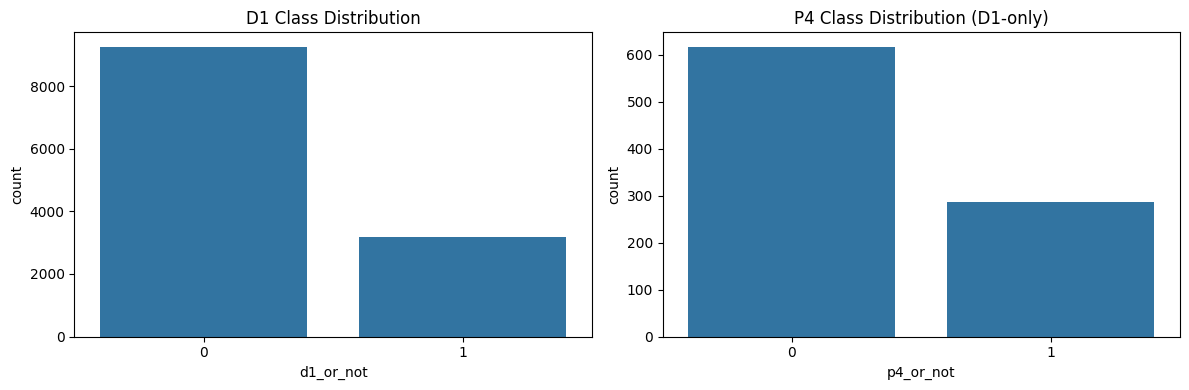

In [4]:
# Quick data quality / EDA

def quick_profile(df: pd.DataFrame, target: str, name: str):
    model_cols = BASE_INPUT_COLS + [target]
    missing = [c for c in model_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{name}: missing required columns: {missing}")

    prof = df[model_cols].copy()
    print(f"\n===== {name} =====")
    print('Rows:', len(prof))
    print('Missing total:', int(prof.isna().sum().sum()))
    print('Target distribution:')
    print(prof[target].value_counts(normalize=True))

    numeric_cols = ['height', 'weight', 'sixty_time', 'exit_velo_max', 'inf_velo']
    print('\nNumeric summary:')
    display(prof[numeric_cols].describe().T)

quick_profile(df_d1_raw, TARGET_D1, 'D1 Modeling Frame')
quick_profile(df_p4_d1_only, TARGET_P4, 'P4 Modeling Frame (D1-only)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(x=TARGET_D1, data=df_d1_raw, ax=axes[0])
axes[0].set_title('D1 Class Distribution')

sns.countplot(x=TARGET_P4, data=df_p4_d1_only, ax=axes[1])
axes[1].set_title('P4 Class Distribution (D1-only)')

plt.tight_layout()
plt.show()


In [5]:
# Feature engineering from allowed raw inputs + constants

def safe_divide(a: pd.Series, b: pd.Series) -> pd.Series:
    b_safe = b.replace(0, np.nan)
    return a / b_safe


def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    # Physics/performance derived features
    out['power_speed'] = safe_divide(out['exit_velo_max'], out['sixty_time'])
    out['velo_by_inf'] = safe_divide(out['exit_velo_max'], out['inf_velo'])
    out['sixty_inv'] = safe_divide(pd.Series(1.0, index=out.index), out['sixty_time'])
    out['height_weight'] = out['height'] * out['weight']

    out['power_per_pound'] = safe_divide(out['exit_velo_max'], out['weight'])
    out['exit_to_sixty_ratio'] = safe_divide(out['exit_velo_max'], out['sixty_time'])
    out['inf_to_sixty_ratio'] = safe_divide(out['inf_velo'], out['sixty_time'])
    out['speed_size_efficiency'] = safe_divide(out['height'] * out['weight'], out['sixty_time'] ** 2)
    out['athletic_index'] = safe_divide(out['power_speed'] * out['height'] * out['weight'], out['sixty_time'])

    # Non-linearities
    out['exit_velo_sq'] = out['exit_velo_max'] ** 2
    out['inf_velo_sq'] = out['inf_velo'] ** 2
    out['sixty_time_sq'] = out['sixty_time'] ** 2
    out['height_sq'] = out['height'] ** 2
    out['weight_sq'] = out['weight'] ** 2

    out['exit_x_inf'] = out['exit_velo_max'] * out['inf_velo']
    out['exit_x_speed'] = out['exit_velo_max'] * out['sixty_inv']
    out['inf_x_speed'] = out['inf_velo'] * out['sixty_inv']

    # Handedness interactions
    for hand_col in ['throwing_hand_R', 'hitting_handedness_R', 'hitting_handedness_S']:
        out[f'exit_{hand_col}'] = out['exit_velo_max'] * out[hand_col]
        out[f'inf_{hand_col}'] = out['inf_velo'] * out[hand_col]
        out[f'sixty_{hand_col}'] = out['sixty_time'] * out[hand_col]

    # Benchmark z-scores + mean-threshold flags
    for level_name, metrics in BENCHMARK_STATS.items():
        level_key = level_name.lower().replace(' ', '_').replace('-', '_')
        for stat_name, stat_meta in metrics.items():
            model_col = 'exit_velo_max' if stat_name == 'exit_velo' else stat_name
            if model_col not in out.columns:
                continue
            mean_val = stat_meta['mean']
            std_val = stat_meta['std']

            if model_col == 'sixty_time':
                # lower is better
                out[f'{model_col}_z_vs_{level_key}'] = (mean_val - out[model_col]) / std_val
                out[f'{model_col}_better_than_{level_key}_mean'] = (out[model_col] <= mean_val).astype(int)
            else:
                out[f'{model_col}_z_vs_{level_key}'] = (out[model_col] - mean_val) / std_val
                out[f'{model_col}_better_than_{level_key}_mean'] = (out[model_col] >= mean_val).astype(int)

    # Composite readiness edges
    zcols_d1 = [
        'exit_velo_max_z_vs_non_p4_d1',
        'inf_velo_z_vs_non_p4_d1',
        'sixty_time_z_vs_non_p4_d1',
        'height_z_vs_non_p4_d1',
        'weight_z_vs_non_p4_d1',
    ]
    zcols_p4 = [
        'exit_velo_max_z_vs_p4',
        'inf_velo_z_vs_p4',
        'sixty_time_z_vs_p4',
        'height_z_vs_p4',
        'weight_z_vs_p4',
    ]
    zcols_non_d1 = [
        'exit_velo_max_z_vs_non_d1',
        'inf_velo_z_vs_non_d1',
        'sixty_time_z_vs_non_d1',
        'height_z_vs_non_d1',
        'weight_z_vs_non_d1',
    ]

    out['d1_readiness_score'] = out[zcols_d1].mean(axis=1)
    out['p4_readiness_score'] = out[zcols_p4].mean(axis=1)
    out['non_d1_readiness_score'] = out[zcols_non_d1].mean(axis=1)

    out['d1_minus_non_d1_edge'] = out['d1_readiness_score'] - out['non_d1_readiness_score']
    out['p4_minus_d1_edge'] = out['p4_readiness_score'] - out['d1_readiness_score']

    # Elite flags from constants
    out['elite_exit_flag'] = (out['exit_velo_max'] >= ELITE_CONSTANTS['ELITE_EXIT_VELO_MAX']).astype(int)
    out['elite_inf_flag'] = (out['inf_velo'] >= ELITE_CONSTANTS['ELITE_INF_VELO']).astype(int)
    out['elite_speed_flag'] = (out['sixty_time'] <= ELITE_CONSTANTS['ELITE_SIXTY_TIME_INF']).astype(int)
    out['elite_height_flag'] = (out['height'] >= ELITE_CONSTANTS['ELITE_HEIGHT_MIN']).astype(int)

    out['elite_count'] = out[['elite_exit_flag', 'elite_inf_flag', 'elite_speed_flag', 'elite_height_flag']].sum(axis=1)

    # Mean-threshold counts
    out['d1_mean_flag_count'] = out[[
        'exit_velo_max_better_than_non_p4_d1_mean',
        'inf_velo_better_than_non_p4_d1_mean',
        'sixty_time_better_than_non_p4_d1_mean',
        'height_better_than_non_p4_d1_mean',
        'weight_better_than_non_p4_d1_mean',
    ]].sum(axis=1)

    out['p4_mean_flag_count'] = out[[
        'exit_velo_max_better_than_p4_mean',
        'inf_velo_better_than_p4_mean',
        'sixty_time_better_than_p4_mean',
        'height_better_than_p4_mean',
        'weight_better_than_p4_mean',
    ]].sum(axis=1)

    return out


In [6]:
# Modeling helpers

class QuantileClipper(BaseEstimator, TransformerMixin):
    # Clip numeric columns to training quantiles to reduce outlier influence.
    def __init__(self, lower: float = 0.01, upper: float = 0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X_df = pd.DataFrame(X)
        self.lower_bounds_ = X_df.quantile(self.lower)
        self.upper_bounds_ = X_df.quantile(self.upper)
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X).copy()
        return X_df.clip(self.lower_bounds_, self.upper_bounds_, axis=1)


def split_indices(y: pd.Series) -> Dict[str, np.ndarray]:
    idx_all = y.index.to_numpy()

    train_val_idx, test_idx = train_test_split(
        idx_all,
        test_size=0.20,
        stratify=y.loc[idx_all],
        random_state=RANDOM_STATE,
    )

    train_idx, val_idx = train_test_split(
        train_val_idx,
        test_size=0.25,
        stratify=y.loc[train_val_idx],
        random_state=RANDOM_STATE,
    )

    return {
        'train': train_idx,
        'val': val_idx,
        'test': test_idx,
    }


def build_pipeline(model, scale: bool = False) -> Pipeline:
    steps = [
        ('imputer', SimpleImputer(strategy='median')),
        ('clipper', QuantileClipper(lower=0.01, upper=0.99)),
    ]
    if scale:
        steps.append(('scaler', StandardScaler()))
    steps.append(('model', model))
    return Pipeline(steps)


def objective_score(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    # Balanced objective that still keeps recall visible.
    ba = balanced_accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
    return float(0.50 * ba + 0.25 * f1 + 0.25 * rec)


def threshold_sweep(y_true: np.ndarray, y_prob: np.ndarray, beta: float = 1.2) -> pd.DataFrame:
    rows = []
    for t in np.linspace(0.10, 0.90, 161):
        y_pred = (y_prob >= t).astype(int)
        rows.append({
            'threshold': float(t),
            'accuracy': accuracy_score(y_true, y_pred),
            'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
            'f1': f1_score(y_true, y_pred, zero_division=0),
            'fbeta': fbeta_score(y_true, y_pred, beta=beta, zero_division=0),
            'recall_pos': recall_score(y_true, y_pred, pos_label=1, zero_division=0),
            'recall_neg': recall_score(y_true, y_pred, pos_label=0, zero_division=0),
            'precision_pos': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
            'objective': objective_score(y_true, y_pred),
        })
    return pd.DataFrame(rows)


def select_threshold(
    sweep_df: pd.DataFrame,
    recall_floor: float = None,
    specificity_floor: float = None,
    optimize_for: str = 'objective',
) -> Tuple[pd.Series, bool, bool]:
    if optimize_for not in {'objective', 'fbeta'}:
        raise ValueError("optimize_for must be 'objective' or 'fbeta'")

    selected_df = sweep_df.copy()

    if recall_floor is not None:
        feasible = selected_df[selected_df['recall_pos'] >= recall_floor]
        recall_floor_met = len(feasible) > 0
        if recall_floor_met:
            selected_df = feasible
        else:
            best_recall = selected_df['recall_pos'].max()
            selected_df = selected_df[selected_df['recall_pos'] == best_recall]
    else:
        recall_floor_met = True

    if specificity_floor is not None:
        feasible_spec = selected_df[selected_df['recall_neg'] >= specificity_floor]
        specificity_floor_met = len(feasible_spec) > 0
        if specificity_floor_met:
            selected_df = feasible_spec
        else:
            best_spec = selected_df['recall_neg'].max()
            selected_df = selected_df[selected_df['recall_neg'] == best_spec]
    else:
        specificity_floor_met = True

    sort_col = 'objective' if optimize_for == 'objective' else 'fbeta'
    selected_row = selected_df.sort_values(
        by=[sort_col, 'precision_pos', 'threshold'],
        ascending=[False, False, False],
    ).iloc[0]

    return selected_row, recall_floor_met, specificity_floor_met


def evaluate_pipeline(
    pipeline: Pipeline,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_val: pd.DataFrame,
    y_val: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    beta: float,
    recall_floor: float = None,
    specificity_floor: float = None,
    threshold_opt_metric: str = 'objective',
) -> Dict[str, Any]:
    pipeline.fit(X_train, y_train)

    val_prob = pipeline.predict_proba(X_val)[:, 1]
    sweep_df = threshold_sweep(y_val.to_numpy(), val_prob, beta=beta)
    val_best, recall_floor_met, specificity_floor_met = select_threshold(
        sweep_df,
        recall_floor=recall_floor,
        specificity_floor=specificity_floor,
        optimize_for=threshold_opt_metric,
    )

    threshold = float(val_best['threshold'])
    val_pred = (val_prob >= threshold).astype(int)

    test_prob = pipeline.predict_proba(X_test)[:, 1]
    test_pred = (test_prob >= threshold).astype(int)

    metrics = {
        'threshold': threshold,
        'val_fbeta': float(val_best['fbeta']),
        'val_objective': float(val_best['objective']),
        'val_recall_pos': float(val_best['recall_pos']),
        'val_precision_pos': float(val_best['precision_pos']),
        'val_recall_neg': float(val_best['recall_neg']),
        'recall_floor': recall_floor,
        'specificity_floor': specificity_floor,
        'recall_floor_met': bool(recall_floor_met),
        'specificity_floor_met': bool(specificity_floor_met),
        'test_accuracy': accuracy_score(y_test, test_pred),
        'test_balanced_accuracy': balanced_accuracy_score(y_test, test_pred),
        'test_f1': f1_score(y_test, test_pred, zero_division=0),
        'test_recall_pos': recall_score(y_test, test_pred, pos_label=1, zero_division=0),
        'test_precision_pos': precision_score(y_test, test_pred, pos_label=1, zero_division=0),
        'test_recall_neg': recall_score(y_test, test_pred, pos_label=0, zero_division=0),
        'test_pred': test_pred,
        'test_prob': test_prob,
        'pipeline': pipeline,
        'y_test': y_test.to_numpy(),
        'val_threshold_sweep': sweep_df,
    }
    return metrics


def model_result_row(model_name: str, res: Dict[str, Any]) -> Dict[str, Any]:
    return {
        'model': model_name,
        'threshold': round(res['threshold'], 3),
        'val_objective': round(res['val_objective'], 4),
        'val_fbeta': round(res['val_fbeta'], 4),
        'val_recall_pos': round(res['val_recall_pos'], 4),
        'recall_floor_met': bool(res.get('recall_floor_met', True)),
        'specificity_floor_met': bool(res.get('specificity_floor_met', True)),
        'test_accuracy': round(res['test_accuracy'], 4),
        'test_balanced_accuracy': round(res['test_balanced_accuracy'], 4),
        'test_f1': round(res['test_f1'], 4),
        'test_recall_pos': round(res['test_recall_pos'], 4),
        'test_recall_neg': round(res['test_recall_neg'], 4),
        'test_precision_pos': round(res['test_precision_pos'], 4),
    }


In [7]:
# Hyperparameter tuning for advanced models

def tune_xgboost(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_val: pd.DataFrame,
    y_val: pd.Series,
    beta: float,
) -> Tuple[Pipeline, Dict[str, Any], float]:
    if not HAS_XGB:
        raise RuntimeError('XGBoost is not available in this environment.')

    def objective(trial: optuna.trial.Trial) -> float:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 200, 1000),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 12.0),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'gamma': trial.suggest_float('gamma', 0.0, 5.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 20.0, log=True),
            'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.8, 4.0),
            'objective': 'binary:logistic',
            'eval_metric': 'logloss',
            'random_state': RANDOM_STATE,
            'n_jobs': -1,
        }

        model = xgb.XGBClassifier(**params)
        pipe = build_pipeline(model, scale=False)
        eval_res = evaluate_pipeline(pipe, X_train, y_train, X_val, y_val, X_val, y_val, beta=beta)
        return eval_res['val_objective']

    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

    best_params = study.best_params
    best_model = xgb.XGBClassifier(
        **best_params,
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    best_pipe = build_pipeline(best_model, scale=False)
    return best_pipe, best_params, float(study.best_value)


def tune_lightgbm(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_val: pd.DataFrame,
    y_val: pd.Series,
    beta: float,
) -> Tuple[Pipeline, Dict[str, Any], float]:
    if not HAS_LGB:
        raise RuntimeError('LightGBM is not available in this environment.')

    def objective(trial: optuna.trial.Trial) -> float:
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 200, 1500),
            'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
            'num_leaves': trial.suggest_int('num_leaves', 15, 255),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 20.0, log=True),
            'class_weight': 'balanced',
            'random_state': RANDOM_STATE,
            'n_jobs': -1,
            'verbose': -1,
        }

        model = lgb.LGBMClassifier(**params)
        pipe = build_pipeline(model, scale=False)
        eval_res = evaluate_pipeline(pipe, X_train, y_train, X_val, y_val, X_val, y_val, beta=beta)
        return eval_res['val_objective']

    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

    best_params = study.best_params
    best_model = lgb.LGBMClassifier(
        **best_params,
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )
    best_pipe = build_pipeline(best_model, scale=False)
    return best_pipe, best_params, float(study.best_value)


def tune_catboost(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_val: pd.DataFrame,
    y_val: pd.Series,
    beta: float,
) -> Tuple[Pipeline, Dict[str, Any], float]:
    if not HAS_CAT:
        raise RuntimeError('CatBoost is not available in this environment.')

    def objective(trial: optuna.trial.Trial) -> float:
        params = {
            'iterations': trial.suggest_int('iterations', 250, 1400),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
            'depth': trial.suggest_int('depth', 4, 10),
            'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-8, 20.0, log=True),
            'random_strength': trial.suggest_float('random_strength', 0.0, 6.0),
            'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 2.0),
            'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.8, 4.0),
            'loss_function': 'Logloss',
            'eval_metric': 'AUC',
            'random_seed': RANDOM_STATE,
            'verbose': False,
        }

        model = cb.CatBoostClassifier(**params)
        pipe = build_pipeline(model, scale=False)
        eval_res = evaluate_pipeline(pipe, X_train, y_train, X_val, y_val, X_val, y_val, beta=beta)
        return eval_res['val_objective']

    study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=RANDOM_STATE))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

    best_params = study.best_params
    best_model = cb.CatBoostClassifier(
        **best_params,
        loss_function='Logloss',
        eval_metric='AUC',
        random_seed=RANDOM_STATE,
        verbose=False,
    )
    best_pipe = build_pipeline(best_model, scale=False)
    return best_pipe, best_params, float(study.best_value)


In [8]:
# Core training routine for one task

def train_task(
    df: pd.DataFrame,
    target_col: str,
    task_name: str,
    beta: float,
    recall_floor: float = None,
    specificity_floor: float = None,
    threshold_opt_metric: str = 'objective',
) -> Dict[str, Any]:
    frame = df[BASE_INPUT_COLS + [target_col]].copy()
    frame = add_engineered_features(frame)

    # Keep two views:
    # 1) raw baseline features only ("original training")
    # 2) engineered feature space for advanced models
    X_raw = frame[BASE_INPUT_COLS].replace([np.inf, -np.inf], np.nan)
    X_eng = frame.drop(columns=[target_col]).replace([np.inf, -np.inf], np.nan)
    y = frame[target_col].astype(int)

    split = split_indices(y)

    X_raw_train, X_raw_val, X_raw_test = (
        X_raw.loc[split['train']],
        X_raw.loc[split['val']],
        X_raw.loc[split['test']],
    )
    X_eng_train, X_eng_val, X_eng_test = (
        X_eng.loc[split['train']],
        X_eng.loc[split['val']],
        X_eng.loc[split['test']],
    )
    y_train, y_val, y_test = (
        y.loc[split['train']],
        y.loc[split['val']],
        y.loc[split['test']],
    )

    print(f"\n{'=' * 90}")
    print(f"{task_name}")
    print(f"Rows: {len(frame)} | Features (raw): {X_raw.shape[1]} | Features (engineered): {X_eng.shape[1]}")
    print(f"Class rate (positive): {y.mean():.3f}")
    if recall_floor is not None:
        print(f"Recall floor (positive class): {recall_floor:.2f}")
    if specificity_floor is not None:
        print(f"Specificity floor (negative class recall): {specificity_floor:.2f}")
    print(f"Train/Val/Test: {len(y_train)}/{len(y_val)}/{len(y_test)}")
    print(f"{'=' * 90}")

    # ------------------------------------------------------------------
    # ORIGINAL TRAINING (Baseline): Logistic Regression on raw features
    # ------------------------------------------------------------------
    baseline_candidates = [0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0]
    baseline_best = None
    baseline_best_c = None

    for c in baseline_candidates:
        logreg = LogisticRegression(
            C=c,
            max_iter=6000,
            class_weight='balanced',
            solver='liblinear',
            random_state=RANDOM_STATE,
        )
        pipe = build_pipeline(logreg, scale=True)
        res = evaluate_pipeline(
            pipe,
            X_raw_train,
            y_train,
            X_raw_val,
            y_val,
            X_raw_test,
            y_test,
            beta=beta,
            recall_floor=recall_floor,
            specificity_floor=specificity_floor,
            threshold_opt_metric=threshold_opt_metric,
        )
        if baseline_best is None or res['val_objective'] > baseline_best['val_objective']:
            baseline_best = res
            baseline_best_c = c

    baseline_result = baseline_best
    baseline_result['model_name'] = f'LogReg Baseline (C={baseline_best_c})'

    # ------------------------------------------------------------------
    # ADVANCED MODELS (engineered features + tuning)
    # ------------------------------------------------------------------
    advanced_results = []

    if HAS_XGB:
        xgb_pipe, xgb_params, xgb_best_val = tune_xgboost(X_eng_train, y_train, X_eng_val, y_val, beta=beta)
        xgb_res = evaluate_pipeline(
            xgb_pipe,
            X_eng_train,
            y_train,
            X_eng_val,
            y_val,
            X_eng_test,
            y_test,
            beta=beta,
            recall_floor=recall_floor,
            specificity_floor=specificity_floor,
            threshold_opt_metric=threshold_opt_metric,
        )
        xgb_res['model_name'] = 'XGBoost (Tuned)'
        xgb_res['best_params'] = xgb_params
        advanced_results.append(xgb_res)

    if HAS_LGB:
        lgb_pipe, lgb_params, lgb_best_val = tune_lightgbm(X_eng_train, y_train, X_eng_val, y_val, beta=beta)
        lgb_res = evaluate_pipeline(
            lgb_pipe,
            X_eng_train,
            y_train,
            X_eng_val,
            y_val,
            X_eng_test,
            y_test,
            beta=beta,
            recall_floor=recall_floor,
            specificity_floor=specificity_floor,
            threshold_opt_metric=threshold_opt_metric,
        )
        lgb_res['model_name'] = 'LightGBM (Tuned)'
        lgb_res['best_params'] = lgb_params
        advanced_results.append(lgb_res)

    if HAS_CAT:
        cat_pipe, cat_params, cat_best_val = tune_catboost(X_eng_train, y_train, X_eng_val, y_val, beta=beta)
        cat_res = evaluate_pipeline(
            cat_pipe,
            X_eng_train,
            y_train,
            X_eng_val,
            y_val,
            X_eng_test,
            y_test,
            beta=beta,
            recall_floor=recall_floor,
            specificity_floor=specificity_floor,
            threshold_opt_metric=threshold_opt_metric,
        )
        cat_res['model_name'] = 'CatBoost (Tuned)'
        cat_res['best_params'] = cat_params
        advanced_results.append(cat_res)

    if not advanced_results:
        print('No advanced model libraries detected; using baseline only.')

    # Weighted soft ensemble from available tuned advanced models
    ensemble_res = None
    if advanced_results:
        val_scores = np.array([max(r['val_objective'], 1e-8) for r in advanced_results], dtype=float)
        weights = val_scores / val_scores.sum()

        val_probs = []
        test_probs = []
        for r in advanced_results:
            pipe = r['pipeline']
            pipe.fit(X_eng_train, y_train)
            val_probs.append(pipe.predict_proba(X_eng_val)[:, 1])
            test_probs.append(pipe.predict_proba(X_eng_test)[:, 1])

        val_probs = np.vstack(val_probs)
        test_probs = np.vstack(test_probs)

        ens_val_prob = np.average(val_probs, axis=0, weights=weights)
        ens_sweep = threshold_sweep(y_val.to_numpy(), ens_val_prob, beta=beta)
        ens_best, ens_recall_floor_met, ens_specificity_floor_met = select_threshold(
            ens_sweep,
            recall_floor=recall_floor,
            specificity_floor=specificity_floor,
            optimize_for=threshold_opt_metric,
        )

        ens_threshold = float(ens_best['threshold'])
        ens_test_prob = np.average(test_probs, axis=0, weights=weights)
        ens_test_pred = (ens_test_prob >= ens_threshold).astype(int)

        ensemble_res = {
            'model_name': 'Weighted Soft Ensemble (Tuned Trees)',
            'threshold': ens_threshold,
            'val_fbeta': float(ens_best['fbeta']),
            'val_objective': float(ens_best['objective']),
            'val_recall_pos': float(ens_best['recall_pos']),
            'val_precision_pos': float(ens_best['precision_pos']),
            'val_recall_neg': float(ens_best['recall_neg']),
            'recall_floor': recall_floor,
            'specificity_floor': specificity_floor,
            'recall_floor_met': bool(ens_recall_floor_met),
            'specificity_floor_met': bool(ens_specificity_floor_met),
            'test_accuracy': accuracy_score(y_test, ens_test_pred),
            'test_balanced_accuracy': balanced_accuracy_score(y_test, ens_test_pred),
            'test_f1': f1_score(y_test, ens_test_pred, zero_division=0),
            'test_recall_pos': recall_score(y_test, ens_test_pred, pos_label=1, zero_division=0),
            'test_precision_pos': precision_score(y_test, ens_test_pred, pos_label=1, zero_division=0),
            'test_recall_neg': recall_score(y_test, ens_test_pred, pos_label=0, zero_division=0),
            'test_pred': ens_test_pred,
            'test_prob': ens_test_prob,
            'pipeline': None,
            'y_test': y_test.to_numpy(),
            'ensemble_weights': {
                advanced_results[i]['model_name']: float(weights[i]) for i in range(len(advanced_results))
            },
            'val_threshold_sweep': ens_sweep,
        }

    def pick_best_model(candidates: List[Dict[str, Any]]) -> Dict[str, Any]:
        feasible = candidates
        if recall_floor is not None:
            recall_feasible = [c for c in feasible if c.get('recall_floor_met', False)]
            if recall_feasible:
                feasible = recall_feasible
        if specificity_floor is not None:
            spec_feasible = [c for c in feasible if c.get('specificity_floor_met', False)]
            if spec_feasible:
                feasible = spec_feasible
        return max(feasible, key=lambda d: d['val_objective'])

    advanced_pool = advanced_results.copy()
    if ensemble_res is not None:
        advanced_pool.append(ensemble_res)

    if advanced_pool:
        best_advanced = pick_best_model(advanced_pool)
    else:
        best_advanced = baseline_result

    # Champion across baseline + advanced models
    full_pool = [baseline_result] + advanced_pool
    best_overall = pick_best_model(full_pool)

    summary_rows = [model_result_row('Original: ' + baseline_result['model_name'], baseline_result)]
    for r in advanced_results:
        summary_rows.append(model_result_row('Advanced: ' + r['model_name'], r))
    if ensemble_res is not None:
        summary_rows.append(model_result_row('Advanced: ' + ensemble_res['model_name'], ensemble_res))

    summary_df = pd.DataFrame(summary_rows).sort_values(
        by=['recall_floor_met', 'specificity_floor_met', 'val_objective', 'test_balanced_accuracy'],
        ascending=[False, False, False, False],
    )

    display(summary_df)
    print(f"Champion model: {best_overall['model_name']}")

    return {
        'task_name': task_name,
        'summary': summary_df,
        'baseline': baseline_result,
        'best_advanced': best_advanced,
        'best_overall': best_overall,
        'all_advanced': advanced_results,
        'ensemble': ensemble_res,
    }


## Train D1 Model (Original Baseline + Advanced Search)

In [9]:
d1_results = train_task(
    df=df_d1_raw,
    target_col=TARGET_D1,
    task_name='D1 vs Non-D1 (Infield)',
    beta=1.2,
    recall_floor=0.75,
    specificity_floor=0.60,
    threshold_opt_metric='objective',
)



D1 vs Non-D1 (Infield)
Rows: 12446 | Features (raw): 8 | Features (engineered): 76
Class rate (positive): 0.257
Recall floor (positive class): 0.75
Specificity floor (negative class recall): 0.60
Train/Val/Test: 7467/2489/2490


[I 2026-03-28 22:26:50,848] A new study created in memory with name: no-name-ce42691a-d13e-455f-9531-bb20171e1829
[I 2026-03-28 22:26:53,680] Trial 0 finished with value: 0.6312504011882636 and parameters: {'n_estimators': 500, 'learning_rate': 0.1667521176194013, 'max_depth': 8, 'min_child_weight': 7.585243326167403, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.5779972601681014, 'gamma': 0.2904180608409973, 'reg_alpha': 0.6245760287469887, 'reg_lambda': 0.003899318902679121, 'scale_pos_weight': 3.0658322489473457}. Best is trial 0 with value: 0.6312504011882636.
[I 2026-03-28 22:26:55,346] Trial 1 finished with value: 0.6532785602503912 and parameters: {'n_estimators': 216, 'learning_rate': 0.17898794163735263, 'max_depth': 9, 'min_child_weight': 3.3357302174610375, 'subsample': 0.6727299868828402, 'colsample_bytree': 0.5917022549267169, 'gamma': 1.5212112147976886, 'reg_alpha': 0.00052821153945323, 'reg_lambda': 0.00010411985985244788, 'scale_pos_weight': 1.7319332486337342

,model,threshold,val_objective,val_fbeta,val_recall_pos,recall_floor_met,specificity_floor_met,test_accuracy,test_balanced_accuracy,test_f1,test_recall_pos,test_recall_neg,test_precision_pos
3,Advanced: CatBoost (Tuned),0.425,0.6855,0.5753,0.7981,True,True,0.6586,0.7028,0.5440,0.7934,0.6121,0.4139
0,Original: LogReg Baseline (C=1.0),0.445,0.6829,0.5727,0.7950,True,True,0.6671,0.7074,0.5492,0.7903,0.6245,0.4208
1,Advanced: XGBoost (Tuned),0.245,0.6814,0.5720,0.7903,True,True,0.6647,0.7053,0.5469,0.7887,0.6218,0.4186
4,Advanced: Weighted Soft Ensemble (Tuned Trees),0.390,0.6812,0.5800,0.7574,True,True,0.6920,0.7119,0.5564,0.7527,0.6710,0.4413
2,Advanced: LightGBM (Tuned),0.425,0.6776,0.5694,0.7809,True,True,0.6622,0.7037,0.5452,0.7887,0.6186,0.4165


Champion model: CatBoost (Tuned)


## Train P4 Model on D1 Players Only (Original Baseline + Advanced Search)

In [10]:
p4_results = train_task(
    df=df_p4_d1_only,
    target_col=TARGET_P4,
    task_name='P4 vs Non-P4 Among D1 Infielders',
    beta=1.0,
    recall_floor=None,
    specificity_floor=0.45,
    threshold_opt_metric='objective',
)



P4 vs Non-P4 Among D1 Infielders
Rows: 903 | Features (raw): 8 | Features (engineered): 76
Class rate (positive): 0.317
Specificity floor (negative class recall): 0.45
Train/Val/Test: 541/181/181


[I 2026-03-28 22:35:41,362] A new study created in memory with name: no-name-359dbed0-468a-4551-929a-9804ba6facf3
[I 2026-03-28 22:35:42,791] Trial 0 finished with value: 0.5715500444660038 and parameters: {'n_estimators': 500, 'learning_rate': 0.1667521176194013, 'max_depth': 8, 'min_child_weight': 7.585243326167403, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.5779972601681014, 'gamma': 0.2904180608409973, 'reg_alpha': 0.6245760287469887, 'reg_lambda': 0.003899318902679121, 'scale_pos_weight': 3.0658322489473457}. Best is trial 0 with value: 0.5715500444660038.
[I 2026-03-28 22:35:43,704] Trial 1 finished with value: 0.5828735144312394 and parameters: {'n_estimators': 216, 'learning_rate': 0.17898794163735263, 'max_depth': 9, 'min_child_weight': 3.3357302174610375, 'subsample': 0.6727299868828402, 'colsample_bytree': 0.5917022549267169, 'gamma': 1.5212112147976886, 'reg_alpha': 0.00052821153945323, 'reg_lambda': 0.00010411985985244788, 'scale_pos_weight': 1.7319332486337342

,model,threshold,val_objective,val_fbeta,val_recall_pos,recall_floor_met,specificity_floor_met,test_accuracy,test_balanced_accuracy,test_f1,test_recall_pos,test_recall_neg,test_precision_pos
0,Original: LogReg Baseline (C=0.1),0.495,0.5405,0.4472,0.6316,True,True,0.5525,0.5691,0.4636,0.6140,0.5242,0.3723
4,Advanced: Weighted Soft Ensemble (Tuned Trees),0.480,0.4808,0.3947,0.5263,True,True,0.5470,0.5319,0.4058,0.4912,0.5726,0.3457
1,Advanced: XGBoost (Tuned),0.490,0.4614,0.3766,0.5088,True,True,0.5801,0.5608,0.4328,0.5088,0.6129,0.3766
3,Advanced: CatBoost (Tuned),0.455,0.4500,0.3660,0.4912,True,True,0.5470,0.5651,0.4605,0.6140,0.5161,0.3684
2,Advanced: LightGBM (Tuned),0.505,0.4443,0.3597,0.4386,True,True,0.5746,0.5426,0.4031,0.4561,0.6290,0.3611


Champion model: LogReg Baseline (C=0.1)


## Final Reports: Original Training vs Best Models

Per your request, this section places the **original baseline training reports** and the **best advanced model reports** side-by-side for direct comparison.



D1 ORIGINAL TRAINING (LOGREG BASELINE)
              precision    recall  f1-score   support

           0     0.8961    0.6245    0.7361      1851
           1     0.4208    0.7903    0.5492       639

    accuracy                         0.6671      2490
   macro avg     0.6585    0.7074    0.6426      2490
weighted avg     0.7742    0.6671    0.6881      2490

Confusion Matrix:
[[1156  695]
 [ 134  505]]

D1 BEST MODEL OVERALL (CatBoost (Tuned))
              precision    recall  f1-score   support

           0     0.8957    0.6121    0.7272      1851
           1     0.4139    0.7934    0.5440       639

    accuracy                         0.6586      2490
   macro avg     0.6548    0.7028    0.6356      2490
weighted avg     0.7720    0.6586    0.6802      2490

Confusion Matrix:
[[1133  718]
 [ 132  507]]

P4 ORIGINAL TRAINING (LOGREG BASELINE, D1-ONLY)
              precision    recall  f1-score   support

           0     0.7471    0.5242    0.6161       124
           1    

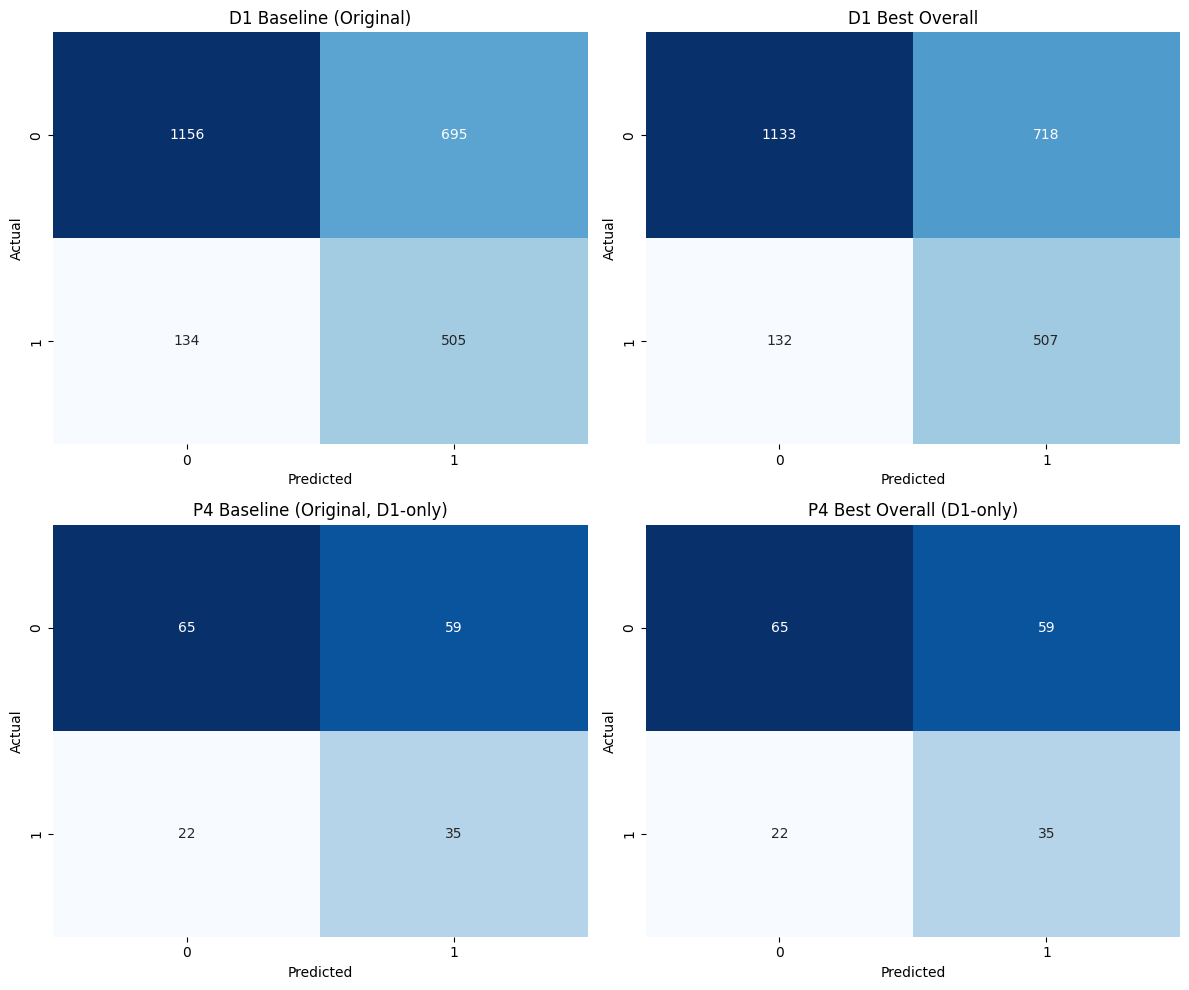

In [11]:
def print_report_block(title: str, y_true: np.ndarray, y_pred: np.ndarray):
    print(f"\n{'=' * 100}")
    print(title)
    print(f"{'=' * 100}")
    print(classification_report(y_true, y_pred, digits=4))
    print('Confusion Matrix:')
    print(confusion_matrix(y_true, y_pred))


def plot_confusion(ax, y_true, y_pred, title: str):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)

# D1 reports
print_report_block(
    'D1 ORIGINAL TRAINING (LOGREG BASELINE)',
    d1_results['baseline']['y_test'],
    d1_results['baseline']['test_pred'],
)
print_report_block(
    f"D1 BEST MODEL OVERALL ({d1_results['best_overall']['model_name']})",
    d1_results['best_overall']['y_test'],
    d1_results['best_overall']['test_pred'],
)

# P4 reports
print_report_block(
    'P4 ORIGINAL TRAINING (LOGREG BASELINE, D1-ONLY)',
    p4_results['baseline']['y_test'],
    p4_results['baseline']['test_pred'],
)
print_report_block(
    f"P4 BEST MODEL OVERALL ({p4_results['best_overall']['model_name']})",
    p4_results['best_overall']['y_test'],
    p4_results['best_overall']['test_pred'],
)

# Confusion matrix dashboard
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_confusion(
    axes[0, 0],
    d1_results['baseline']['y_test'],
    d1_results['baseline']['test_pred'],
    'D1 Baseline (Original)',
)
plot_confusion(
    axes[0, 1],
    d1_results['best_overall']['y_test'],
    d1_results['best_overall']['test_pred'],
    'D1 Best Overall',
)
plot_confusion(
    axes[1, 0],
    p4_results['baseline']['y_test'],
    p4_results['baseline']['test_pred'],
    'P4 Baseline (Original, D1-only)',
)
plot_confusion(
    axes[1, 1],
    p4_results['best_overall']['y_test'],
    p4_results['best_overall']['test_pred'],
    'P4 Best Overall (D1-only)',
)

plt.tight_layout()
plt.show()


In [12]:
# Compact metric comparison for easy model selection

def compact_compare(task_res: Dict[str, Any], task_label: str) -> pd.DataFrame:
    baseline = task_res['baseline']
    best = task_res['best_overall']

    rows = [
        {
            'task': task_label,
            'model_group': 'Original',
            'model_name': baseline['model_name'],
            'threshold': round(baseline['threshold'], 3),
            'val_recall_pos': baseline['val_recall_pos'],
            'recall_floor_met': baseline.get('recall_floor_met', True),
            'specificity_floor_met': baseline.get('specificity_floor_met', True),
            'accuracy': baseline['test_accuracy'],
            'balanced_accuracy': baseline['test_balanced_accuracy'],
            'f1': baseline['test_f1'],
            'recall_pos': baseline['test_recall_pos'],
            'specificity': baseline['test_recall_neg'],
            'precision_pos': baseline['test_precision_pos'],
        },
        {
            'task': task_label,
            'model_group': 'Best Overall',
            'model_name': best['model_name'],
            'threshold': round(best['threshold'], 3),
            'val_recall_pos': best['val_recall_pos'],
            'recall_floor_met': best.get('recall_floor_met', True),
            'specificity_floor_met': best.get('specificity_floor_met', True),
            'accuracy': best['test_accuracy'],
            'balanced_accuracy': best['test_balanced_accuracy'],
            'f1': best['test_f1'],
            'recall_pos': best['test_recall_pos'],
            'specificity': best['test_recall_neg'],
            'precision_pos': best['test_precision_pos'],
        },
    ]

    return pd.DataFrame(rows)

final_compare = pd.concat([
    compact_compare(d1_results, 'D1 vs Non-D1'),
    compact_compare(p4_results, 'P4 vs Non-P4 (D1-only)'),
], ignore_index=True)

for c in ['val_recall_pos', 'accuracy', 'balanced_accuracy', 'f1', 'recall_pos', 'specificity', 'precision_pos']:
    final_compare[c] = final_compare[c].round(4)

display(final_compare)

if p4_results.get('ensemble') is not None and 'ensemble_weights' in p4_results['ensemble']:
    print('P4 ensemble weights:', p4_results['ensemble']['ensemble_weights'])
if d1_results.get('ensemble') is not None and 'ensemble_weights' in d1_results['ensemble']:
    print('D1 ensemble weights:', d1_results['ensemble']['ensemble_weights'])


,task,model_group,model_name,threshold,val_recall_pos,recall_floor_met,specificity_floor_met,accuracy,balanced_accuracy,f1,recall_pos,specificity,precision_pos
0,D1 vs Non-D1,Original,LogReg Baseline (C=1.0),0.445,0.7950,True,True,0.6671,0.7074,0.5492,0.7903,0.6245,0.4208
1,D1 vs Non-D1,Best Overall,CatBoost (Tuned),0.425,0.7981,True,True,0.6586,0.7028,0.5440,0.7934,0.6121,0.4139
2,P4 vs Non-P4 (D1-only),Original,LogReg Baseline (C=0.1),0.495,0.6316,True,True,0.5525,0.5691,0.4636,0.6140,0.5242,0.3723
3,P4 vs Non-P4 (D1-only),Best Overall,LogReg Baseline (C=0.1),0.495,0.6316,True,True,0.5525,0.5691,0.4636,0.6140,0.5242,0.3723


P4 ensemble weights: {'XGBoost (Tuned)': 0.34035579772110747, 'LightGBM (Tuned)': 0.32771497015402257, 'CatBoost (Tuned)': 0.33192923212487}
D1 ensemble weights: {'XGBoost (Tuned)': 0.33329126251868063, 'LightGBM (Tuned)': 0.3314339460228345, 'CatBoost (Tuned)': 0.3352747914584849}


## Notes

- This notebook intentionally **does not rely on region/position/external scouting features**.
- All added features are generated from user-entered raw fields + benchmark constants.
- To push scores further, increase `N_TRIALS`, and optionally rerun with different random seeds for stability checks.
